In [2]:
# import numpy as np
import pandas as pd

# import matplotlib.pyplot as plt 
# import seaborn as sns

# import joblib


# %matplotlib inline

### Parsing the caliberated CFLIB library data in dataframe using tab delimiter

In [3]:
df = pd.read_csv("asu (2).tsv", delimiter = "\t", encoding = "latin1")

In [4]:
df.head()

,n_Name,Name,SpType,Teff,e_Teff,log(g),e_log(g),[Fe/H],e_[Fe/H],r_[Fe/H],SimbadName,_RA,_DE
0,,,,K,K,[cm/s2],[cm/s2],[Sun],[Sun],,,deg,deg
1,-,----------,------------,-----,----,-----,-----,-----,-----,--,----------,---------,---------
2,,HD000249,K1IV,4757,28,2.88,0.09,-0.29,0.06,0,HD000249,001.84401,+26.45060
3,,HD000358,B8IVmnp...,12307,180,4.14,0.07,0.38,0.09,0,HD000358,002.09691,+29.09043
4,,HD000400,F8IV,6215,45,4.18,0.07,-0.24,0.07,0,HD000400,002.17058,+36.62712


Encoding the Name column from unicode format to string format

In [5]:
# df[df["Name"] == "HD000249"]

def encoding(value):
    return value.encode("utf-8")  # converts unicode to str

df["Name"] = df["Name"].apply(encoding)

type(df["Name"][3])  # should now be <type 'str'>

bytes

In [24]:
df[df["Name"] == b'HD005750  ']

,n_Name,Name,SpType,Teff,e_Teff,log(g),e_log(g),[Fe/H],e_[Fe/H],r_[Fe/H],SimbadName,_RA,_DE
44,,b'HD005750 ',F5,6330,47,4.21,0.06,-0.42,0.07,0,HD005750,014.89926,+32.49211


In [ ]:
df["Name"]

0                b' '
1       b'----------'
2       b'HD000249  '
3       b'HD000358  '
4       b'HD000400  '
            ...      
1270    b'G_90-25   '
1271    b'G_95-4    '
1272    b'G_95-57   '
1273    b'G_96-20   '
1274    b'NGP_29_129'
Name: Name, Length: 1275, dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   n_Name      1275 non-null   object
 1   Name        1275 non-null   object
 2   SpType      1275 non-null   object
 3   Teff        1275 non-null   object
 4   e_Teff      1275 non-null   object
 5   log(g)      1275 non-null   object
 6   e_log(g)    1275 non-null   object
 7   [Fe/H]      1275 non-null   object
 8   e_[Fe/H]    1275 non-null   object
 9   r_[Fe/H]    1275 non-null   object
 10  SimbadName  1275 non-null   object
 11  _RA         1275 non-null   object
 12  _DE         1275 non-null   object
dtypes: object(13)
memory usage: 129.6+ KB


In [17]:
df["SpType"]

0                   
1       ------------
2       K1IV        
3       B8IVmnp...  
4       F8IV        
            ...     
1270    sdG2        
1271    G0          
1272    K1V         
1273    F8          
1274    K1V         
Name: SpType, Length: 1275, dtype: object

In [5]:
# df.drop([0,1], inplace = True)

In [6]:
# df.reset_index(drop = True, inplace= True)

In [7]:
# df.head()

#### Testing the interpolator pipeline

In [8]:
INTERPOLATOR_MODEL = 'RF_base_model_pvk.sav'
STANDARD_SCALER = 'rf_standard_scale_pvk.sav'

In [9]:
import scipy 

print(scipy.__version__)
print(scipy.__file__)

1.1.0
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/scipy/__init__.pyc


In [10]:


from sklearn.externals import joblib
model = joblib.load("RF_base_model_pvk.sav")
print(type(model))

# import joblib
# model = joblib.load("RF_base_model_pvk.sav")
# print(type(model))



/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


<class 'sklearn.ensemble.forest.RandomForestRegressor'>


/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator RandomForestRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


In [11]:
sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator StandardScaler from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

In [14]:
pred = InterpolateSpectrum(5040,3.5,0.0)

In [15]:
wave = 3500. + np.arange(4306, dtype=np.float)*0.4
len(wave)
max(wave)


5222.0

In [16]:
wave[1] - wave[0]

0.40000000000009095

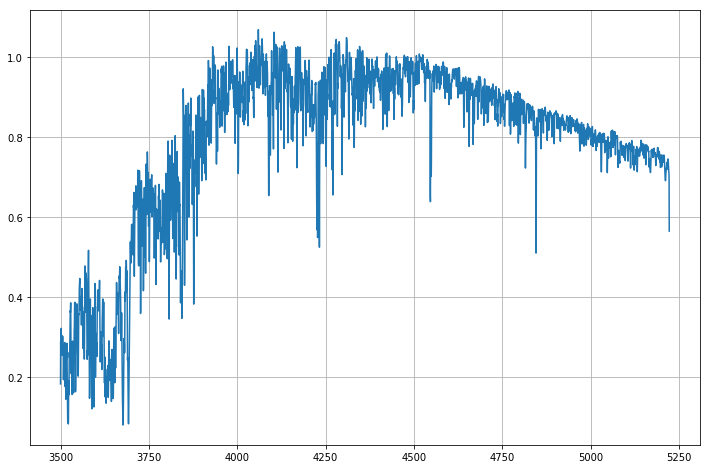

In [17]:
plt.figure(figsize=(12,8))
plt.plot(wave,pred[0,:])
plt.grid()
plt.show()

Looking for start, stop and step value for wavelength axis 

In [18]:
#step value : 
wave[1] - wave[0]

0.40000000000009095

In [19]:
#start value 
wave[0]

3500.0

In [20]:
#stop value
max(wave)

5222.0

In [21]:
# length of the wavelength array 
len(wave)

4306

Reducing the range of the wavelength axis of the fits data according to the interpolator wavelength : 

In [22]:
import pandas as pd
import numpy as np